# Movie Rental Store Analysis

This notebook is written in a simple way so students can follow each step.

We will first understand the data, then import all CSV files, clean the important columns, explain every merge step, build one master table, and calculate business insights.


## 1. About the Data

This project contains data from a movie rental store.

- `rental.csv` shows when a movie was rented and when it was returned.
- `payment.csv` shows the money paid for each rental.
- `inventory.csv` tells us which film copy was rented from which store.
- `film.csv` contains movie details such as title, rating, rental rate, rental duration, and length.
- `film_category.csv` and `category.csv` help us understand movie categories.
- `customer.csv` contains customer details.
- `actor.csv` and `film_actor.csv` connect actors to films.
- `address.csv`, `city.csv`, and `country.csv` store location information.
- `staff.csv` and `store.csv` describe store operations.
- `language.csv` stores movie language information.

So this dataset helps us study rentals, revenue, movies, customers, and store operations.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## 2. Import All CSV Files

We import every CSV file in the project with normal `pd.read_csv()` statements.

Even if all tables are not used in the final master table, importing all of them helps us understand the full project data.


In [2]:
actor = pd.read_csv("actor.csv")
address = pd.read_csv("address.csv")
category = pd.read_csv("category.csv")
city = pd.read_csv("city.csv")
country = pd.read_csv("country.csv")
customer = pd.read_csv("customer.csv")
film = pd.read_csv("film.csv")
film_actor = pd.read_csv("film_actor.csv")
film_category = pd.read_csv("film_category.csv")
inventory = pd.read_csv("inventory.csv")
language = pd.read_csv("language.csv")
payment = pd.read_csv("payment.csv")
rental = pd.read_csv("rental.csv")
staff = pd.read_csv("staff.csv")
store = pd.read_csv("store.csv")


In [3]:
print("Rows in actor:", len(actor))
print("Rows in address:", len(address))
print("Rows in category:", len(category))
print("Rows in city:", len(city))
print("Rows in country:", len(country))
print("Rows in customer:", len(customer))
print("Rows in film:", len(film))
print("Rows in film_actor:", len(film_actor))
print("Rows in film_category:", len(film_category))
print("Rows in inventory:", len(inventory))
print("Rows in language:", len(language))
print("Rows in payment:", len(payment))
print("Rows in rental:", len(rental))
print("Rows in staff:", len(staff))
print("Rows in store:", len(store))

print()
print("Rental sample")
print(rental.head())

print()
print("Payment sample")
print(payment.head())

print()
print("Film sample")
print(film.head())


Rows in actor: 200
Rows in address: 603
Rows in category: 16
Rows in city: 600
Rows in country: 109
Rows in customer: 599
Rows in film: 1000
Rows in film_actor: 5462
Rows in film_category: 1000
Rows in inventory: 4581
Rows in language: 6
Rows in payment: 16049
Rows in rental: 16044
Rows in staff: 2
Rows in store: 2

Rental sample
   rental_id                rental_date  inventory_id  customer_id  \
0          2  2005-05-25 03:24:33+05:30          1525          459   
1          3  2005-05-25 03:33:39+05:30          1711          408   
2          4  2005-05-25 03:34:41+05:30          2452          333   
3          5  2005-05-25 03:35:21+05:30          2079          222   
4          6  2005-05-25 03:38:07+05:30          2792          549   

                 return_date  staff_id                last_update  
0  2005-05-29 00:10:33+05:30         1  2020-02-16 08:00:53+05:30  
1  2005-06-02 02:42:39+05:30         1  2020-02-16 08:00:53+05:30  
2  2005-06-03 06:13:41+05:30         2  202

## 3. Clean the Main Analysis Tables

We imported all files, but for the revenue analysis we mainly use rental, payment, inventory, film, category, and customer tables.

Here we convert the main date columns and check the most important missing values and duplicate keys.


In [4]:
customer["create_date"] = pd.to_datetime(customer["create_date"], errors="coerce")
customer["last_update"] = pd.to_datetime(customer["last_update"], errors="coerce")
film["last_update"] = pd.to_datetime(film["last_update"], errors="coerce")
inventory["last_update"] = pd.to_datetime(inventory["last_update"], errors="coerce")
payment["payment_date"] = pd.to_datetime(payment["payment_date"], errors="coerce")
rental["rental_date"] = pd.to_datetime(rental["rental_date"], errors="coerce")
rental["return_date"] = pd.to_datetime(rental["return_date"], errors="coerce")
rental["last_update"] = pd.to_datetime(rental["last_update"], errors="coerce")

if "original_language_id" in film.columns:
    if film["original_language_id"].isna().all():
        film = film.drop(columns=["original_language_id"])


In [5]:
print("Missing values")
print("rental")
print(rental[["rental_id", "return_date"]].isnull().sum())

print()
print("payment")
print(payment[["payment_id", "rental_id", "amount", "payment_date"]].isnull().sum())

print()
print("film")
print(film.isnull().sum())

print()
print("Duplicate primary keys")
print("rental_id duplicates:", rental["rental_id"].duplicated().sum())
print("payment_id duplicates:", payment["payment_id"].duplicated().sum())
print("film_id duplicates:", film["film_id"].duplicated().sum())
print("customer_id duplicates:", customer["customer_id"].duplicated().sum())


Missing values
rental
rental_id        0
return_date    183
dtype: int64

payment
payment_id      0
rental_id       0
amount          0
payment_date    0
dtype: int64

film
film_id             0
title               0
description         0
release_year        0
language_id         0
rental_duration     0
rental_rate         0
length              0
replacement_cost    0
rating              0
last_update         0
special_features    0
fulltext            0
dtype: int64

Duplicate primary keys
rental_id duplicates: 0
payment_id duplicates: 0
film_id duplicates: 0
customer_id duplicates: 0


## 4. Prepare Payment Data Before the Merge

Sometimes one rental can have more than one payment record.

We group the payment table by `rental_id` so that each rental has one payment summary row. We do this before merging because we want the final master table to have one row for one rental.


In [6]:
payment_summary = payment.groupby("rental_id", as_index=False).agg(
    total_amount=("amount", "sum"),
    first_payment_date=("payment_date", "min"),
)

print("Rows in payment summary:", len(payment_summary))
print(payment_summary.head())


Rows in payment summary: 16044
   rental_id  total_amount               first_payment_date
0          1          2.99 2020-01-25 02:51:56.996577+05:30
1          2          2.99 2020-01-25 02:52:59.996577+05:30
2          3          3.99 2020-01-25 03:02:05.996577+05:30
3          4          4.99 2020-01-25 03:03:07.996577+05:30
4          5          6.99 2020-01-25 03:03:47.996577+05:30


## 5. Merge Step 1: Add Payment Information

We merge `rental` with `payment_summary` using `rental_id`.

Why do we do this?
- The rental table tells us which rental happened.
- The payment table tells us how much money was collected.
- After this merge, each rental row also has payment amount and payment date.

This helps us calculate revenue for each rental.


In [7]:
master_df = rental.merge(
    payment_summary,
    on="rental_id",
    how="left",
)

print(master_df.head())


   rental_id               rental_date  inventory_id  customer_id  \
0          2 2005-05-25 03:24:33+05:30          1525          459   
1          3 2005-05-25 03:33:39+05:30          1711          408   
2          4 2005-05-25 03:34:41+05:30          2452          333   
3          5 2005-05-25 03:35:21+05:30          2079          222   
4          6 2005-05-25 03:38:07+05:30          2792          549   

                return_date  staff_id               last_update  total_amount  \
0 2005-05-29 00:10:33+05:30         1 2020-02-16 08:00:53+05:30          2.99   
1 2005-06-02 02:42:39+05:30         1 2020-02-16 08:00:53+05:30          3.99   
2 2005-06-03 06:13:41+05:30         2 2020-02-16 08:00:53+05:30          4.99   
3 2005-06-02 09:03:21+05:30         1 2020-02-16 08:00:53+05:30          6.99   
4 2005-05-27 06:02:07+05:30         1 2020-02-16 08:00:53+05:30          0.99   

                first_payment_date  
0 2020-01-25 02:52:59.996577+05:30  
1 2020-01-25 03:02:05.99

## 6. Merge Step 2: Add Film ID from Inventory

We merge `master_df` with `inventory` using `inventory_id`.

Why do we do this?
- The rental table has `inventory_id`, not `film_id`.
- The inventory table tells us which film copy belongs to that inventory item.
- After this merge, we know which film was rented and which store owned that copy.

This merge creates the bridge from a rental to the actual movie.


In [8]:
master_df = master_df.merge(
    inventory[["inventory_id", "film_id", "store_id"]],
    on="inventory_id",
    how="left",
)

print(master_df.head())


   rental_id               rental_date  inventory_id  customer_id  \
0          2 2005-05-25 03:24:33+05:30          1525          459   
1          3 2005-05-25 03:33:39+05:30          1711          408   
2          4 2005-05-25 03:34:41+05:30          2452          333   
3          5 2005-05-25 03:35:21+05:30          2079          222   
4          6 2005-05-25 03:38:07+05:30          2792          549   

                return_date  staff_id               last_update  total_amount  \
0 2005-05-29 00:10:33+05:30         1 2020-02-16 08:00:53+05:30          2.99   
1 2005-06-02 02:42:39+05:30         1 2020-02-16 08:00:53+05:30          3.99   
2 2005-06-03 06:13:41+05:30         2 2020-02-16 08:00:53+05:30          4.99   
3 2005-06-02 09:03:21+05:30         1 2020-02-16 08:00:53+05:30          6.99   
4 2005-05-27 06:02:07+05:30         1 2020-02-16 08:00:53+05:30          0.99   

                first_payment_date  film_id  store_id  
0 2020-01-25 02:52:59.996577+05:30      33

## 7. Merge Step 3: Add Film Details

We merge `master_df` with `film` using `film_id`.

Why do we do this?
- Now we already know the `film_id`.
- The film table gives us the title, rental rate, rental duration, length, and rating.
- After this merge, we can compare revenue and rental behavior across different movies.

This merge adds the movie information needed for analysis.


In [9]:
master_df = master_df.merge(
    film[["film_id", "title", "rental_duration", "rental_rate", "length", "rating"]],
    on="film_id",
    how="left",
)

print(master_df.head())


   rental_id               rental_date  inventory_id  customer_id  \
0          2 2005-05-25 03:24:33+05:30          1525          459   
1          3 2005-05-25 03:33:39+05:30          1711          408   
2          4 2005-05-25 03:34:41+05:30          2452          333   
3          5 2005-05-25 03:35:21+05:30          2079          222   
4          6 2005-05-25 03:38:07+05:30          2792          549   

                return_date  staff_id               last_update  total_amount  \
0 2005-05-29 00:10:33+05:30         1 2020-02-16 08:00:53+05:30          2.99   
1 2005-06-02 02:42:39+05:30         1 2020-02-16 08:00:53+05:30          3.99   
2 2005-06-03 06:13:41+05:30         2 2020-02-16 08:00:53+05:30          4.99   
3 2005-06-02 09:03:21+05:30         1 2020-02-16 08:00:53+05:30          6.99   
4 2005-05-27 06:02:07+05:30         1 2020-02-16 08:00:53+05:30          0.99   

                first_payment_date  film_id  store_id            title  \
0 2020-01-25 02:52:59.99

## 8. Merge Step 4: Build a Category Lookup Table

We merge `film_category` with `category` using `category_id`.

Why do we do this?
- `film_category.csv` tells us which category ID belongs to each film.
- `category.csv` gives the readable category name.
- After this merge, we create a small lookup table that connects each film to a category name.

This is useful because category names are easier to understand than category IDs.


In [10]:
category_lookup = film_category.merge(
    category[["category_id", "name"]],
    on="category_id",
    how="left",
)
category_lookup = category_lookup.rename(columns={"name": "category_name"})

print(category_lookup.head())


   film_id  category_id                last_update category_name
0        1            6  2020-02-15 15:37:09+05:30   Documentary
1        2           11  2020-02-15 15:37:09+05:30        Horror
2        3            6  2020-02-15 15:37:09+05:30   Documentary
3        4           11  2020-02-15 15:37:09+05:30        Horror
4        5            8  2020-02-15 15:37:09+05:30        Family


## 9. Merge Step 5: Add Category Name to the Master Table

We merge `master_df` with `category_lookup` using `film_id`.

Why do we do this?
- We already know the `film_id` for each rental.
- The category lookup tells us the category name of that film.
- After this merge, each rental row has a readable movie category.

This lets us answer questions like which category earns the most revenue.


In [11]:
master_df = master_df.merge(
    category_lookup[["film_id", "category_name"]],
    on="film_id",
    how="left",
)

print(master_df.head())


   rental_id               rental_date  inventory_id  customer_id  \
0          2 2005-05-25 03:24:33+05:30          1525          459   
1          3 2005-05-25 03:33:39+05:30          1711          408   
2          4 2005-05-25 03:34:41+05:30          2452          333   
3          5 2005-05-25 03:35:21+05:30          2079          222   
4          6 2005-05-25 03:38:07+05:30          2792          549   

                return_date  staff_id               last_update  total_amount  \
0 2005-05-29 00:10:33+05:30         1 2020-02-16 08:00:53+05:30          2.99   
1 2005-06-02 02:42:39+05:30         1 2020-02-16 08:00:53+05:30          3.99   
2 2005-06-03 06:13:41+05:30         2 2020-02-16 08:00:53+05:30          4.99   
3 2005-06-02 09:03:21+05:30         1 2020-02-16 08:00:53+05:30          6.99   
4 2005-05-27 06:02:07+05:30         1 2020-02-16 08:00:53+05:30          0.99   

                first_payment_date  film_id  store_id            title  \
0 2020-01-25 02:52:59.99

## 10. Merge Step 6: Add Customer Details

We merge `master_df` with `customer` using `customer_id`.

Why do we do this?
- The rental table already has the customer ID.
- The customer table gives us the customer name and store information.
- After this merge, we can identify the customers behind the rentals.

This helps us study customer behavior and find top customers.


In [12]:
master_df = master_df.merge(
    customer[["customer_id", "first_name", "last_name", "store_id"]],
    on="customer_id",
    how="left",
    suffixes=("", "_customer"),
)

print(master_df.head())


   rental_id               rental_date  inventory_id  customer_id  \
0          2 2005-05-25 03:24:33+05:30          1525          459   
1          3 2005-05-25 03:33:39+05:30          1711          408   
2          4 2005-05-25 03:34:41+05:30          2452          333   
3          5 2005-05-25 03:35:21+05:30          2079          222   
4          6 2005-05-25 03:38:07+05:30          2792          549   

                return_date  staff_id               last_update  total_amount  \
0 2005-05-29 00:10:33+05:30         1 2020-02-16 08:00:53+05:30          2.99   
1 2005-06-02 02:42:39+05:30         1 2020-02-16 08:00:53+05:30          3.99   
2 2005-06-03 06:13:41+05:30         2 2020-02-16 08:00:53+05:30          4.99   
3 2005-06-02 09:03:21+05:30         1 2020-02-16 08:00:53+05:30          6.99   
4 2005-05-27 06:02:07+05:30         1 2020-02-16 08:00:53+05:30          0.99   

                first_payment_date  film_id  store_id            title  \
0 2020-01-25 02:52:59.99

## 11. Create New Columns

Now we create a few simple features that help our analysis.

- `actual_duration_days`: how many days the movie was kept
- `rental_month`: month name of the rental
- `rental_day_name`: day name of the rental
- `payment_day`: payment date without the time part
- `is_overdue`: whether the movie was kept longer than the allowed rental duration
- `length_group`: short, medium, or long film


In [13]:
master_df["actual_duration_days"] = (
    master_df["return_date"] - master_df["rental_date"]
).dt.days
master_df["rental_month"] = master_df["rental_date"].dt.month_name()
master_df["rental_day_name"] = master_df["rental_date"].dt.day_name()
master_df["payment_day"] = master_df["first_payment_date"].dt.date
master_df["is_overdue"] = master_df["actual_duration_days"] > master_df["rental_duration"]
master_df["length_group"] = pd.cut(
    master_df["length"],
    bins=[0, 90, 120, 200],
    labels=["Short", "Medium", "Long"],
)

print("Master table shape:", master_df.shape)
print()
print(master_df.head())


Master table shape: (16044, 26)

   rental_id               rental_date  inventory_id  customer_id  \
0          2 2005-05-25 03:24:33+05:30          1525          459   
1          3 2005-05-25 03:33:39+05:30          1711          408   
2          4 2005-05-25 03:34:41+05:30          2452          333   
3          5 2005-05-25 03:35:21+05:30          2079          222   
4          6 2005-05-25 03:38:07+05:30          2792          549   

                return_date  staff_id               last_update  total_amount  \
0 2005-05-29 00:10:33+05:30         1 2020-02-16 08:00:53+05:30          2.99   
1 2005-06-02 02:42:39+05:30         1 2020-02-16 08:00:53+05:30          3.99   
2 2005-06-03 06:13:41+05:30         2 2020-02-16 08:00:53+05:30          4.99   
3 2005-06-02 09:03:21+05:30         1 2020-02-16 08:00:53+05:30          6.99   
4 2005-05-27 06:02:07+05:30         1 2020-02-16 08:00:53+05:30          0.99   

                first_payment_date  film_id  ...  category_name f

## 12. KPI Calculation

Now we calculate the main business results from the final master table.


In [14]:
returned_rentals = master_df[master_df["return_date"].notna()]

total_revenue = payment["amount"].sum()
merged_revenue = master_df["total_amount"].sum()
total_rentals = master_df["rental_id"].nunique()
average_rental_value = master_df["total_amount"].mean()
open_rentals = master_df["return_date"].isna().sum()
overdue_rate = returned_rentals["is_overdue"].mean() * 100

top_categories = (
    master_df.groupby("category_name", as_index=False)["total_amount"]
    .sum()
    .sort_values("total_amount", ascending=False)
    .head(5)
)

top_customers = (
    master_df.groupby(["customer_id", "first_name", "last_name"], as_index=False)["total_amount"]
    .sum()
    .sort_values("total_amount", ascending=False)
    .head(5)
)

print(f"Total revenue from payment table: ${total_revenue:,.2f}")
print(f"Total revenue from master table: ${merged_revenue:,.2f}")
print(f"Total rentals: {total_rentals:,}")
print(f"Average rental value: ${average_rental_value:.2f}")
print(f"Open rentals: {open_rentals}")
print(f"Overdue rate: {overdue_rate:.2f}%")

print()
print("Top categories by revenue")
print(top_categories.to_string(index=False))

print()
print("Top customers by revenue")
print(top_customers.to_string(index=False))


Total revenue from payment table: $67,416.51
Total revenue from master table: $67,416.51
Total rentals: 16,044
Average rental value: $4.20
Open rentals: 183
Overdue rate: 40.37%

Top categories by revenue
category_name  total_amount
       Sports       5314.21
       Sci-Fi       4756.98
    Animation       4656.30
        Drama       4587.39
       Comedy       4383.58

Top customers by revenue
 customer_id first_name last_name  total_amount
         526       KARL      SEAL        221.55
         148    ELEANOR      HUNT        216.54
         144      CLARA      SHAW        195.58
         178     MARION    SNYDER        194.61
         137     RHONDA   KENNEDY        194.61


## 13. Simple Charts

These charts help us understand payment values, popular movie ratings, top categories, and the revenue trend over time.


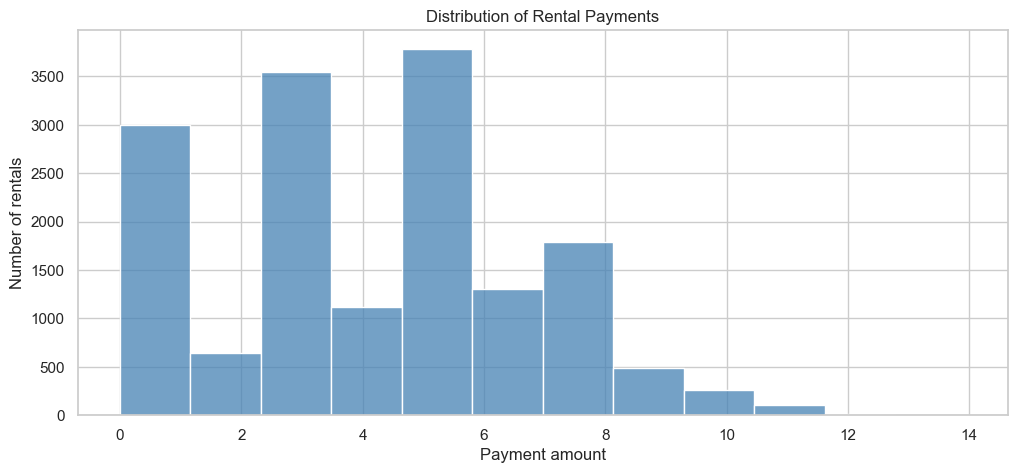

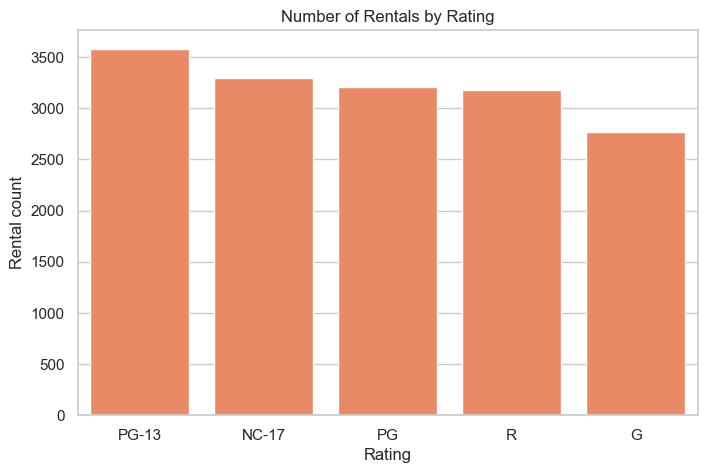

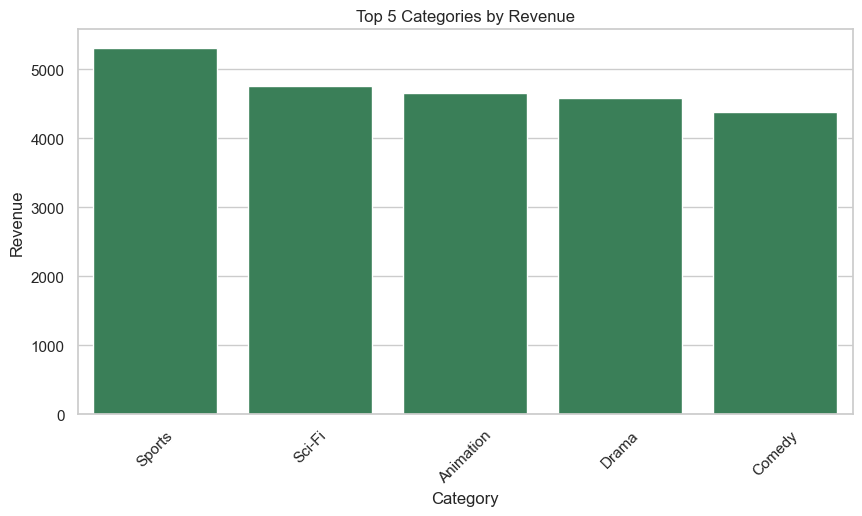

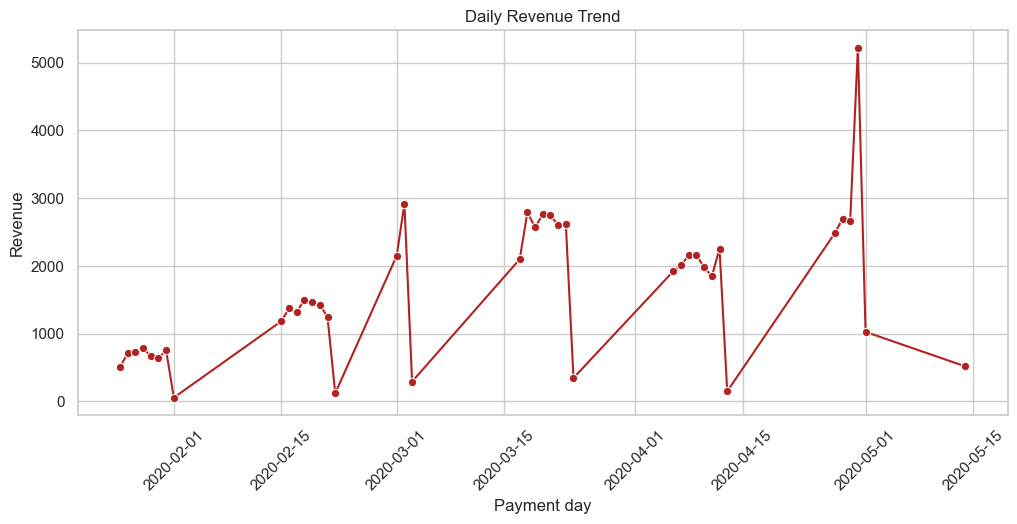

In [15]:
rating_counts = master_df["rating"].value_counts().reset_index()
rating_counts.columns = ["rating", "movie_count"]

daily_revenue = (
    master_df.groupby("payment_day", as_index=False)["total_amount"]
    .sum()
    .sort_values("payment_day")
)
daily_revenue["payment_day"] = pd.to_datetime(daily_revenue["payment_day"])

plt.figure(figsize=(12, 5))
sns.histplot(master_df["total_amount"].dropna(), bins=12, color="steelblue")
plt.title("Distribution of Rental Payments")
plt.xlabel("Payment amount")
plt.ylabel("Number of rentals")
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=rating_counts, x="rating", y="movie_count", color="coral")
plt.title("Number of Rentals by Rating")
plt.xlabel("Rating")
plt.ylabel("Rental count")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=top_categories, x="category_name", y="total_amount", color="seagreen")
plt.title("Top 5 Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_revenue, x="payment_day", y="total_amount", marker="o", color="firebrick")
plt.title("Daily Revenue Trend")
plt.xlabel("Payment day")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()


## 14. Final Simple Summary

This last part gives a short summary in simple words.


In [16]:
most_common_rating = rating_counts.iloc[0]["rating"]
best_category = top_categories.iloc[0]["category_name"]
best_customer = top_customers.iloc[0]["first_name"] + " " + top_customers.iloc[0]["last_name"]

print("This data is about a movie rental store.")
print("Most common rating:", most_common_rating)
print("Highest revenue category:", best_category)
print("Highest spending customer:", best_customer)


This data is about a movie rental store.
Most common rating: PG-13
Highest revenue category: Sports
Highest spending customer: KARL SEAL
